In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)
ATAC_data.head() #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50


### <h1>ATAC_seq: Data Cleanup</h1>

<h2>Removing or imputing missing values</h2>

In [2]:
#number of rows
ATAC_data.__len__() 

512595

In [3]:
#number of missing data points per column
missing_values_count = ATAC_data.isnull().sum()
missing_values_count[missing_values_count > 0] #just show columes where data is missing

Included.in.systematic.analysis    177716
TSS                                498303
genes.within.100Kb                  84885
dtype: int64

**Data is missing in 3 columes**: Included.in.systematic.analysis, TSS, genes.within.100Kb  

**included in systematic analysis**: Boolean / yes-no flag indicating whether the authors considered this OCR reliable enough for downstream analyses in the paper
--> NaN: Yoshida et al. do not considerd it reliabale enough for further analysis and did't includ it in further analysis 

**TSS**: name of closest TSS gene
--> NaN: there isn't any TSS gene close to the peak

**genes within 100kb**: just lists all the genes in that range as str
--> NaN: If the peaks are not near any genes within 100 kb

In [4]:
# Wie viel prozent der cells sind missing values
total_cells = np.prod(ATAC_data.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
percent_missing

np.float64(1.5147097670894654)

In [5]:
#values of TSS that are not NaN
just_TSS = ATAC_data.loc[~ATAC_data ["TSS"].isnull(), "TSS"]
just_TSS

20           Xkr4
139        Mrpl15
145        Lypla1
157         Tcea1
159         Tcea1
           ...   
512467      Vamp7
512477      Tmlhe
512506    Eif2s3y
512522        Uty
512532      Ddx3y
Name: TSS, Length: 14292, dtype: str

In [6]:
#Wie viele prozent cells missing in TSS (enhancer)
TSS_total_missing = ATAC_data ["TSS"]. isnull().sum()
TSS_total_cells = len(ATAC_data)
print(ATAC_data ["TSS"]. notnull().sum())

percent_missing_TSS = (TSS_total_missing/TSS_total_cells) * 100
print(percent_missing_TSS)

14292
97.21183390395926


es fehlen **97%** der werte in TSS --> weil diese nicht in der Nähe einer TSS sind --> distal enahncers

In [7]:
#values of Included.in.systematic.analysis	 that are not NaN
ATAC_data["Included.in.systematic.analysis"].notnull().sum()

just_Incl_sa = ATAC_data.loc[ATAC_data["Included.in.systematic.analysis"].notnull(),"Included.in.systematic.analysis"]
just_Incl_sa

2         1.0
3         1.0
5         1.0
6         1.0
7         1.0
         ... 
512587    1.0
512588    1.0
512589    1.0
512590    1.0
512591    1.0
Name: Included.in.systematic.analysis, Length: 334879, dtype: float64

**Rauswerfen Daten nicht reliabel Sysematic analysis of paper**
--> also included in systematic analysis = NaN

<h3>P-value filtering

In [8]:
Minimum_pvalues = ATAC_data["_-log10_bestPvalue"].min()
ATAC_data.sort_values(by=["_-log10_bestPvalue"])

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
64295,ImmGenATAC1219.peak_64296,chr10,122421608,0.00,0.00,NaN,NaN,Avpr1a,0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.34,0.11,0.11,0.11
508409,ImmGenATAC1219.peak_508410,chrX,106733598,0.00,0.00,NaN,NaN,NaN,0.41,0.10,...,0.10,0.29,0.11,0.47,0.52,0.14,0.10,0.11,0.51,0.11
506621,ImmGenATAC1219.peak_506622,chrX,80992224,0.67,0.22,NaN,NaN,Tmem47,0.41,0.10,...,0.44,0.36,0.11,0.11,0.11,0.53,0.10,2.16,1.61,0.11
501817,ImmGenATAC1219.peak_501818,chrUn_GL456390,17745,0.00,0.23,NaN,NaN,NaN,0.41,0.10,...,0.10,0.10,0.71,0.11,0.11,0.14,0.26,0.53,0.51,0.11
450165,ImmGenATAC1219.peak_450166,chr8,3343174,0.00,0.23,NaN,NaN,"Insr,A430078G23Rik,Arhgef18",0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.10,0.11,0.64,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212977,ImmGenATAC1219.peak_212978,chr17,34000401,0.25,inf,1.0,H2-K1,"Platr17,BC051226,Daxx,Zbtb22,Tapbp,Rgl2,Pfdn6,...",57.63,52.34,...,104.36,106.10,79.63,115.50,103.96,66.25,98.69,98.72,66.62,110.97
501969,ImmGenATAC1219.peak_501970,chrUn_JH584304,55702,0.51,inf,1.0,NaN,Pisd-ps3,159.55,163.88,...,85.79,92.83,412.74,47.16,64.12,43.49,141.82,36.14,95.08,27.71
501973,ImmGenATAC1219.peak_501974,chrUn_JH584304,59065,0.00,inf,1.0,NaN,Pisd-ps3,90.52,145.41,...,253.14,174.38,321.14,225.03,225.22,108.31,225.58,108.38,282.02,256.03
501975,ImmGenATAC1219.peak_501976,chrUn_JH584304,59733,0.00,inf,1.0,Pisd-ps3,Pisd-ps3,727.42,727.42,...,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42


In [9]:
logp_threshold_data = ATAC_data[ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)]
len(logp_threshold_data)

150265

**Teil von p value filtering: colume: _-log10_bestPvalue**

<br> untersuchen Datnesätze nach auffälligen niedrigen vs hohen p-values

wenn 0 dann heißt es p-value 1 --> Effekt wahrscheinlich rein zufällig zufällig (**entfernen?**)
wenn inf dann p-value fast 0 Sehr signifikant 

logp_threshold alle die kleiner sind als ein p von 0.05 --> signifikante Werte

inf als 0 ersetzen?

*TO BE CONTINUED*

In [10]:
not_Incl_sa = ATAC_data["Included.in.systematic.analysis"].isnull()
logp_threshold_data = ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)
ATAC_data[not_Incl_sa & logp_threshold_data]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
10,ImmGenATAC1219.peak_11,chr1,3445768,0.00,0.84,NaN,NaN,NaN,0.41,0.10,...,0.87,0.54,0.11,1.37,0.11,0.11,0.98,1.12,1.04,0.11
12,ImmGenATAC1219.peak_13,chr1,3505885,0.01,0.62,NaN,NaN,NaN,0.41,0.71,...,0.44,0.54,0.23,0.11,0.51,1.59,2.23,1.33,3.39,0.93
15,ImmGenATAC1219.peak_16,chr1,3535704,0.03,1.09,NaN,NaN,NaN,0.41,0.10,...,1.70,1.41,2.58,0.95,0.11,1.56,0.88,1.33,1.23,7.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512563,ImmGenATAC1219.peak_512564,chrY,90797463,0.00,0.65,NaN,NaN,Erdr1,2.36,0.10,...,1.60,1.83,0.66,1.39,2.19,0.50,0.75,0.90,1.04,0.11
512566,ImmGenATAC1219.peak_512567,chrY,90798663,0.00,0.91,NaN,NaN,Erdr1,0.41,2.57,...,2.23,1.79,0.23,0.47,3.63,2.82,1.75,1.73,1.64,1.03
512574,ImmGenATAC1219.peak_512575,chrY,90802747,0.00,1.21,NaN,NaN,Erdr1,0.41,0.10,...,1.93,0.36,0.59,2.24,2.90,1.61,1.91,3.83,1.64,2.97
512592,ImmGenATAC1219.peak_512593,chrY,90813175,0.00,0.69,NaN,NaN,Erdr1,0.41,0.71,...,0.44,1.38,1.20,1.37,1.82,1.61,1.29,0.14,1.23,0.50


<p style="color: pink;">Pre-Filtering in Yoshida </p>
included in systematic analysis Werte die NaN sind, haben yoshida et al. rausgenommen, weil die Ihnen zu unverlässig waren. <br>
Wir haben alle Werte gefiltert die ein größeren p value haben als 0.05, also für uns nicht verlässlich. Diese sind weniger als die Yoshida et al. nicht included haben, aber alle 150265 fallen darunter.

**ATAC_data_removed**: Datensatz ohne  unreliable data

In [11]:
threshold = -np.log10(0.05)
ATAC_data_removed = ATAC_data[ATAC_data["_-log10_bestPvalue"] >= threshold].copy()
ATAC_data_removed.head()
ATAC_data_removed.__len__() 

362330

<h2>Filtering low-signal peaks or low-variance features</h2>

<h2>Identifying and addressing potential batch effects

<h2> Removing technical outlier samples (only when there is a clear technical justification)


<h2> Ensuring correct data types </h2> 
<br>(numeric values encoded as numbers, categorical variables handled appropriately)


<h2> Re-ordering rows and columns in meaningful ways to aid interpretation


### <h2> Exploration of data nach Tilmann

In [12]:
pd.set_option("display.max_rows", None)      
ATAC_data_removed.describe()
ATAC_data_removed.__len__()

/Users/rosavasila/topic04_team03/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


362330

count    # Anzahl der nicht-NaN Werte
mean     # Mittelwert ohne NaN
std      # Standardabweichung ohne NaN

**--> NaN doch lieber ersetzen?**

<h3> Creating a function for log-tranformation </h3>
log transformation besser, um Werte zu vergleichen

In [13]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

<h3> Using the log_transform function on the filtered values and creating a histogram </h3>

In [14]:
log_ATAC = log_transform(ATAC_data_removed)
log_ATAC.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,14.953379,0.067659,2.468100,0.693147,NaN,NaN,1.211941,0.095310,...,0.625938,0.431782,1.313724,0.667829,0.104360,4.164803,2.294553,0.845868,0.712950,0.104360
3,ImmGenATAC1219.peak_4,chr1,14.953820,0.139762,1.391282,0.693147,NaN,NaN,0.343590,0.095310,...,0.364643,1.040277,0.506818,0.104360,0.652325,2.674149,0.683097,0.824175,0.712950,0.104360
4,ImmGenATAC1219.peak_5,chr1,15.031250,0.029559,0.837248,NaN,NaN,NaN,0.343590,0.095310,...,0.364643,0.095310,0.506818,1.026042,0.412110,0.652325,0.559616,0.845868,0.959350,1.704748
5,ImmGenATAC1219.peak_6,chr1,15.039056,0.058269,1.220830,0.693147,NaN,NaN,1.211941,0.970779,...,0.850151,0.254642,0.207014,0.636577,0.104360,0.425268,0.875469,0.641854,1.353255,2.311545
6,ImmGenATAC1219.peak_7,chr1,15.039320,0.364643,1.272566,0.693147,NaN,NaN,0.343590,0.095310,...,0.625938,1.075002,0.463734,0.104360,0.871293,1.275363,0.559616,1.193922,1.205971,2.486572


<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

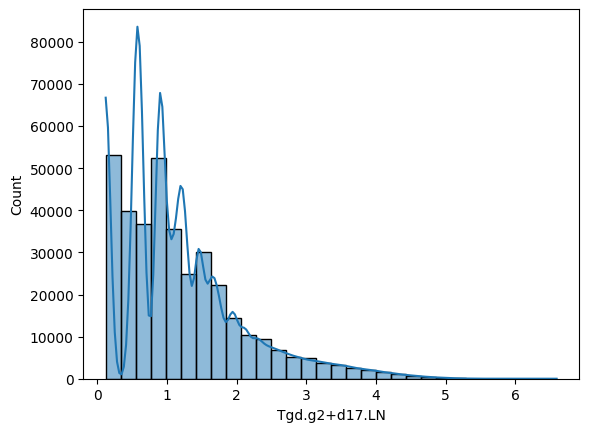

In [15]:
sns.histplot(log_ATAC["Tgd.g2+d17.LN"], bins=30, kde=True)

**Verteilung rechtsschief:**
<br> sehr viele Peaks/Regionen haben niedrige ATAC-Signale
<br>wenige Peaks/Regionen haben hohe ATAC-Signale
<br>der lange rechte Schwanz zeigt: einige, aber weige Regionen sind besonders stark zugänglich/open chromatin

## Filtering by Variation

In [17]:
exclude_cols = [
    "ImmGenATAC1219.peakID",
    "chrom",
    "Summit",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

log_ATAC_celltypes = log_ATAC.drop(columns=exclude_cols).copy()
log_ATAC_celltypes.head()

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,1.211941,0.095310,0.641854,0.104360,0.385262,0.095310,0.405465,0.774727,0.277632,0.131028,...,0.625938,0.431782,1.313724,0.667829,0.104360,4.164803,2.294553,0.845868,0.712950,0.104360
3,0.343590,0.095310,0.104360,0.104360,0.582216,0.336472,0.405465,1.172482,0.587787,0.131028,...,0.364643,1.040277,0.506818,0.104360,0.652325,2.674149,0.683097,0.824175,0.712950,0.104360
4,0.343590,0.095310,0.104360,0.104360,0.385262,0.292670,1.022451,0.774727,0.277632,0.470004,...,0.364643,0.095310,0.506818,1.026042,0.412110,0.652325,0.559616,0.845868,0.959350,1.704748
5,1.211941,0.970779,1.047319,0.947789,0.751416,0.292670,0.350657,0.122218,0.587787,0.470004,...,0.850151,0.254642,0.207014,0.636577,0.104360,0.425268,0.875469,0.641854,1.353255,2.311545
6,0.343590,0.095310,0.104360,0.104360,0.104360,0.850151,0.641854,0.989541,0.587787,0.470004,...,0.625938,1.075002,0.463734,0.104360,0.871293,1.275363,0.559616,1.193922,1.205971,2.486572


<Axes: ylabel='Count'>

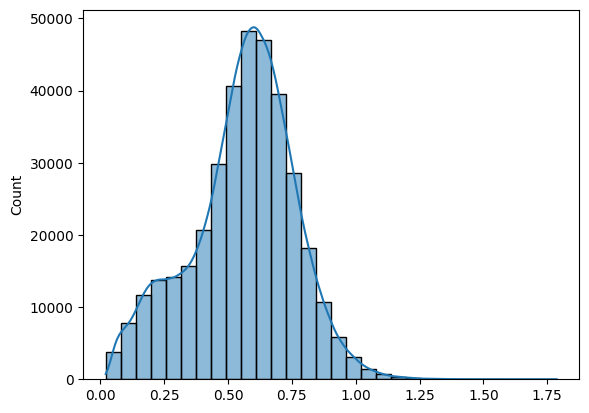

In [22]:
OCR_var_coef = log_ATAC_celltypes.std(axis=1) / log_ATAC_celltypes.mean(axis=1)
sns.histplot(OCR_var_coef, bins=30, kde=True)

In [ ]:
OCR_var_coef.describe()

In [23]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(OCR_var_coef.mean(axis=1)), OCR_var_coef, s=5, cmap='viridis', alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

ValueError: No axis named 1 for object type Series

<Figure size 1000x700 with 0 Axes>